<a href="https://colab.research.google.com/github/saikrishnajadhav2006-netizen/CodeFlowViz-2.0/blob/main/churn_modelling_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [139]:
import kagglehub
path = kagglehub.dataset_download("rjmanoj/credit-card-customer-churn-prediction")

Using Colab cache for faster access to the 'credit-card-customer-churn-prediction' dataset.


# New Section

In [140]:

import os
import pandas as pd

In [141]:
df = pd.read_csv(os.path.join(path, "Churn_Modelling.csv"))
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [142]:
print(df.shape)

(10000, 14)


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [144]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [145]:
df.duplicated().sum()

np.int64(0)

In [146]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [147]:
df.drop('RowNumber',axis=1,inplace=True)

In [148]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [149]:
df.drop('CustomerId',axis=1,inplace=True)


In [150]:
df.drop('Surname',axis=1,inplace=True)

In [151]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [152]:
df=pd.get_dummies(df,columns=['Geography','Gender'], drop_first=True,dtype=int)

In [153]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


df

In [154]:
df.shape
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [155]:
x=df.drop(columns=['Exited'])
y=df['Exited']


In [156]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_test

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
6252,596,32,3,96709.07,2,0,0,41788.37,1,0,1
4684,623,43,1,0.00,2,1,1,146379.30,0,0,1
1731,601,44,4,0.00,2,1,0,58561.31,0,1,0
4742,506,59,8,119152.10,2,1,1,170679.74,1,0,1
4521,560,27,7,124995.98,1,1,1,114669.79,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6412,602,53,5,98268.84,1,0,1,45038.29,1,0,0
8285,609,25,10,0.00,1,0,1,109895.16,0,0,1
7853,730,47,7,0.00,1,1,0,33373.26,0,0,0
1095,692,29,4,0.00,1,1,0,76755.99,0,0,1


In [157]:
x_train.shape
y_train

,Exited
9254,0
1561,0
1670,1
6087,1
6669,1
...,...
5734,0
5191,0
5390,1
860,1


In [158]:
x_test.shape
y_test

,Exited
6252,0
4684,0
1731,0
4742,0
4521,0
...,...
6412,1
8285,0
7853,1
1095,1


In [159]:
y_train.shape

(8000,)

In [160]:
y_test.shape

(2000,)

In [161]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [162]:
x_train

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [163]:
x_test

array([[-0.57749609, -0.6557859 , -0.69539349, ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.29729735,  0.3900109 , -1.38944225, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.52560743,  0.48508334, -0.3483691 , ..., -0.57946723,
         1.73494238, -1.09499335],
       ...,
       [ 0.81311987,  0.77030065,  0.69270405, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.41876609, -0.94100321, -0.3483691 , ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.24540869,  0.00972116, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [164]:
import tensorflow

In [165]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [166]:
model=Sequential()
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [167]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [168]:
model.compile(loss='binary_crossentropy',optimizer='Adam')

In [169]:
history=model.fit(x_train, y_train, epochs=10,validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.4834 - val_loss: 1.1786
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0827 - val_loss: 0.9251
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9283 - val_loss: 0.8578
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8023 - val_loss: 0.7000
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6353 - val_loss: 0.5852
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5718 - val_loss: 0.5429
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5388 - val_loss: 0.5552
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5147 - val_loss: 0.5135
Epoch 9/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4976 - val_loss: 0.4839
Epoch 10/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4951 - val_loss: 0.5218


In [170]:
model.layers[1].get_weights()

[array([[ 0.0104849 , -0.2489181 , -0.13590853, -0.13246825,  0.325883  ,
          0.19348696, -0.22399624,  0.14925088, -0.17226915,  0.104303  ,
          0.14075236],
        [-0.2967469 , -0.00264299,  0.07479805, -0.46270505, -0.25824243,
          0.36011714,  0.02120651,  0.13513352,  0.03094988, -0.44128644,
          0.08489092],
        [ 0.17099203,  0.22560829, -0.24280022,  0.18687876, -0.01810308,
         -0.35290393, -0.28541085,  0.26923034, -0.37109095,  0.26618823,
         -0.17354664],
        [ 0.4126233 , -0.6861437 ,  0.142297  ,  0.40211216, -0.5852322 ,
          0.30088168, -0.08900598,  0.14736158, -0.30253616,  0.41157034,
          0.33090046],
        [-0.260534  , -0.49217233,  0.42212966, -0.21266331, -0.08681623,
          0.43372253,  0.39743042, -0.35570922,  0.3153921 , -0.2982311 ,
         -0.4389462 ],
        [-0.00154543, -0.08711541, -0.04368839, -0.13193384,  0.31653124,
          0.2898015 , -0.3167171 ,  0.3883841 , -0.19133836,  0.2095019

In [171]:
x_pre=model.predict(x_test)
import numpy as np
x_pred=np.where(x_pre>0.5,1,0)
x_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0],
       [0],
       [1],
       ...,
       [1],
       [0],
       [0]])

In [172]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
accuracy_score(y_test,x_pred)
print(accuracy_score(y_test,x_pred) * 100)

79.0


In [173]:
import matplotlib.pyplot as plt
history.history

{'loss': [1.4833941459655762,
  1.082728385925293,
  0.9283277988433838,
  0.8022567629814148,
  0.6353111267089844,
  0.5717893838882446,
  0.5388413071632385,
  0.5146565437316895,
  0.49762198328971863,
  0.4951353967189789],
 'val_loss': [1.1786491870880127,
  0.9250604510307312,
  0.8578068614006042,
  0.7000169157981873,
  0.5852272510528564,
  0.5428738594055176,
  0.5551840662956238,
  0.5134640336036682,
  0.48392999172210693,
  0.5218350291252136]}

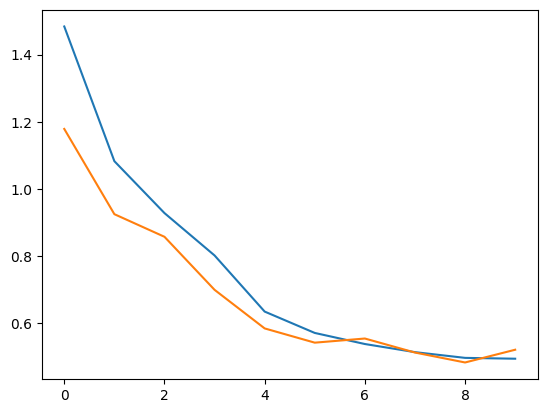

In [175]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])